In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%204/Day%202/Diabetes%20prediction%20dataset.zip"
df = pd.read_csv(url, compression='zip')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())
df.head()

Shape: (100000, 9)

Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Missing values: 0


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# Exercises XP — Diabetes Classification

## Exercise 1: Understanding the Problem and Data Collection

**Problem:** predict whether an individual has diabetes (binary classification: 0 = no, 1 = yes) based on health and demographic features.

In [2]:
print("Class balance:")
print(df['diabetes'].value_counts())
print(f"\nPositive (diabetes) cases: {(df['diabetes']==1).sum()} ({(df['diabetes']==1).mean()*100:.1f}%)")
print(f"Negative (no diabetes) cases: {(df['diabetes']==0).sum()} ({(df['diabetes']==0).mean()*100:.1f}%)")

Class balance:
diabetes
0    91500
1     8500
Name: count, dtype: int64

Positive (diabetes) cases: 8500 (8.5%)
Negative (no diabetes) cases: 91500 (91.5%)


This dataset is highly imbalanced: 100,000 individuals total, only 8.5% (8,500) have diabetes. This means accuracy alone will be a misleading metric — a model predicting "no diabetes" every single time would already score 91.5% accuracy without learning anything useful. Precision, Recall, and F1-score (as emphasized in the Credit Card Fraud lesson) will be essential for judging this model honestly.

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test class balance:", y_test.value_counts(normalize=True).round(3).to_dict())

Train shape: (80000, 8)
Test shape: (20000, 8)

Train class balance: {0: 0.915, 1: 0.085}
Test class balance: {0: 0.915, 1: 0.085}


## Exercise 2: Model Picking and Standardization

**Which model, and why?** Logistic Regression is the appropriate choice here — this is a binary classification problem (diabetes: yes/no), which is exactly the shape of problem Logistic Regression is built for, as covered in today's lesson. It also outputs a probability rather than just a hard label, which is valuable in a medical context — a doctor may want to know "72% likely" rather than just a flat yes/no.

**Do we need to standardize?** Yes. Logistic Regression is sensitive to the scale of input features — look at our columns: `age` ranges roughly 0-80, `blood_glucose_level` ranges up to 300, while `hypertension`/`heart_disease` are just 0/1. Without standardization, features with naturally larger numbers (like blood glucose) could dominate the model's learning simply due to their scale, not because they're actually more medically important.

In [4]:
print("Unique values in gender:", df['gender'].unique())
print("Unique values in smoking_history:", df['smoking_history'].unique())

Unique values in gender: <StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
Unique values in smoking_history: <StringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str


In [5]:
X_train_encoded = pd.get_dummies(X_train, columns=['gender', 'smoking_history'])
X_test_encoded = pd.get_dummies(X_test, columns=['gender', 'smoking_history'])

X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print("Shape after encoding:", X_train_encoded.shape)
print("\nColumns:", X_train_encoded.columns.tolist())

Shape after encoding: (80000, 15)

Columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Female', 'gender_Male', 'gender_Other', 'smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Before scaling - age range:", X_train_encoded['age'].min(), "to", X_train_encoded['age'].max())
print("After scaling - age range:", X_train_scaled[:, 0].min().round(2), "to", X_train_scaled[:, 0].max().round(2))

Before scaling - age range: 0.08 to 80.0
After scaling - age range: -1.86 to 1.69


## Exercise 3: Model Training

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Model trained successfully.")
print("First 10 predictions:", y_pred[:10])
print("First 10 actual values:", y_test.values[:10])

Model trained successfully.
First 10 predictions: [0 0 0 0 0 0 0 1 0 1]
First 10 actual values: [0 0 0 0 0 0 0 1 0 0]


## Exercise 4: Evaluation Metrics

In [8]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy: 0.9605 (96.05%)


Confusion Matrix:
[[18122   178]
 [  612  1088]]


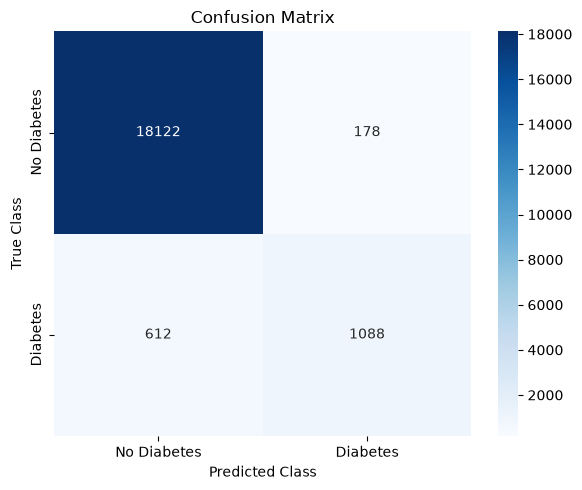

In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

class_names = ['No Diabetes', 'Diabetes']
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

The confusion matrix reveals what accuracy hid: the model correctly identifies most non-diabetes cases (18,122 true negatives), but misses 612 out of 1,700 actual diabetes cases (a 36% miss rate) — only catching 1,088 (64%) as true positives. In a medical screening context, these 612 false negatives are the most concerning error type, since these individuals would not be flagged for further testing or care despite actually having diabetes.

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall (Sensitivity): {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score: {f1:.4f}")

Precision: 0.8594 (85.94%)
Recall (Sensitivity): 0.6400 (64.00%)
F1-Score: 0.7336


**Precision (85.94%):** of everyone the model flagged as diabetic, 86% actually were — few false alarms.
**Recall (64.00%):** of everyone who actually has diabetes, the model only caught 64% — missing over a third of real cases.
**F1-Score (0.7336):** a single balanced score combining both.

For a medical screening context, this model's cautious bias (high precision, lower recall) is arguably the wrong tradeoff — missing a real diabetes case (a false negative) is typically more costly than one extra unnecessary follow-up test (a false positive). A real deployment might deliberately lower the decision threshold to catch more true positives, accepting somewhat lower precision in exchange.

## Exercise 5: Visualizing the Decision Boundary

Since our full model uses 15 features (impossible to visualize directly), this section trains a separate, simplified 2D model using only `HbA1c_level` and `blood_glucose_level` — two of the most clinically direct diabetes indicators — purely to visualize how the decision boundary looks. This is for visualization only; it does not replace the full 15-feature model evaluated above.

In [11]:
X_2d = df[['HbA1c_level', 'blood_glucose_level']].values
y_2d = df['diabetes'].values

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)

scaler_2d = StandardScaler()
X_2d_train_scaled = scaler_2d.fit_transform(X_2d_train)
X_2d_test_scaled = scaler_2d.transform(X_2d_test)

model_2d = LogisticRegression()
model_2d.fit(X_2d_train_scaled, y_2d_train)

acc_2d = accuracy_score(y_2d_test, model_2d.predict(X_2d_test_scaled))
print(f"2D model accuracy (for visualization): {acc_2d:.4f}")

2D model accuracy (for visualization): 0.9562


The simplified 2-feature model achieves 95.62% accuracy, barely below the full 15-feature model's 96.05%. This suggests `HbA1c_level` and `blood_glucose_level` carry the vast majority of the real predictive signal for diabetes — consistent with real medical knowledge, since both are standard clinical markers used to diagnose diabetes directly.

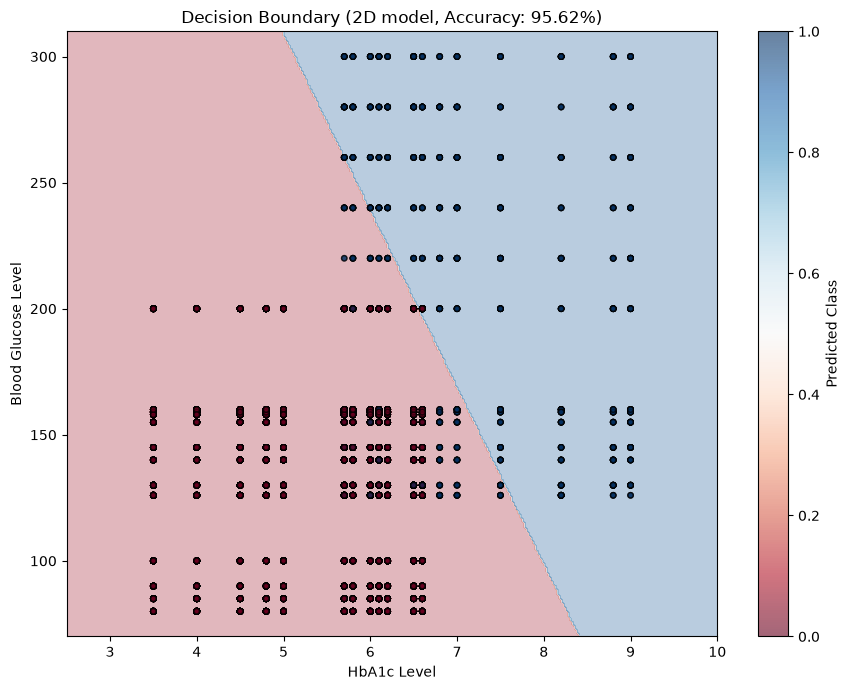

In [12]:
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 10, X_2d[:, 1].max() + 10
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

grid_scaled = scaler_2d.transform(np.c_[xx.ravel(), yy.ravel()])
Z = model_2d.predict(grid_scaled).reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.scatter(X_2d_test[:, 0], X_2d_test[:, 1], c=y_2d_test, cmap='RdBu', edgecolors='k', s=15, alpha=0.6)
plt.xlabel('HbA1c Level')
plt.ylabel('Blood Glucose Level')
plt.title(f'Decision Boundary (2D model, Accuracy: {acc_2d:.2%})')
plt.colorbar(label='Predicted Class')
plt.tight_layout()
plt.show()

The decision boundary is a clean diagonal split, consistent with real clinical understanding — higher HbA1c and blood glucose together push a prediction toward diabetic (blue region). The boundary's steeper lean along the HbA1c axis suggests the model weights HbA1c slightly more heavily than blood glucose level when making its prediction, though both clearly contribute to the outcome.

## Exercise 6: ROC Curve

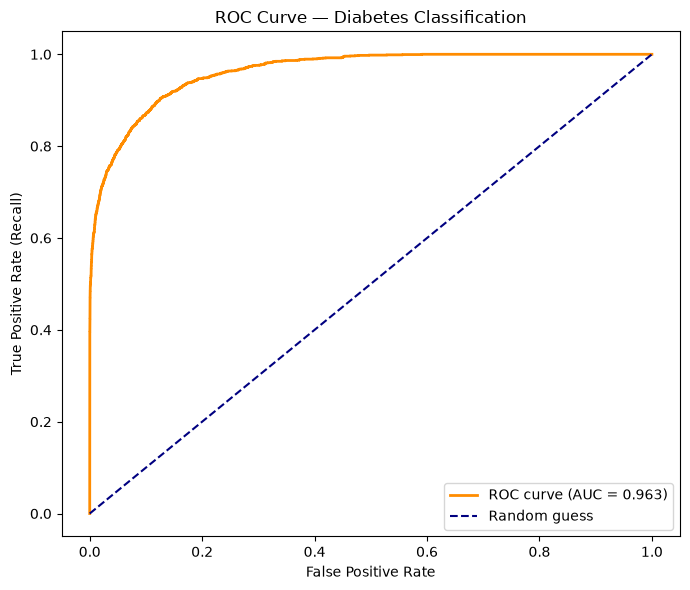

AUC Score: 0.9625


In [13]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', linewidth=2, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Diabetes Classification')
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.4f}")

The AUC of 0.963 indicates excellent underlying discriminative ability — very close to the maximum of 1.0, and far above the 0.5 "random guessing" baseline (dashed line). This resolves the earlier recall concern from Exercise 4: the model itself is highly capable of distinguishing diabetic from non-diabetic cases; the 64% recall we saw was a consequence of the default 50% decision threshold, not a limitation of the model's learned patterns. The curve shows that lowering the threshold could substantially improve recall (catching more real diabetes cases) at only a modest cost in false positives — a worthwhile trade-off for a medical screening context, where missing a real case is costlier than an extra follow-up test.